# 06 Compound Water Stress Index

**Series:** Tribal Water Monitoring  
**Author:** Lilly Jones, PhD, Daear Consulting, LLC  
**Primary Focus:** Pine Ridge (Oglala Lakota), Rosebud (Sicangu Lakota)  
**Collective:** Oceti Sakowin  
**Inputs:** Notebooks 02, 03, 04, 05

## Purpose
Individual indicators such as groundwater level, streamflow stage, and drought index 
each tell part of the story. But the most dangerous water stress conditions
occur when multiple indicators are bad simultaneously:
- Groundwater levels declining
- AND streamflow at emergency stage
- AND drought persisting

The Compound Water Stress Index (CWSI) synthesizes these into a single
annual score (0–1) to help water managers see the big picture and
identify which years were genuinely dangerous vs. which had one bad
indicator offset by better conditions elsewhere.

## Design Principles
**Transparent.** Every component, weight, and calculation
step is visible. A water manager can ask "why is 2012 the highest stress
year?" and get a clear answer.

**Configurable weights.** The default weighting (GW 40%, flow 30%,
drought 30%) is in `config.yaml`. Adjust in consultation with Tribal
water staff who know which indicator matters most for their community.

**Model Patching.** If one component is missing, the index is
computed from the available components with redistributed weights.
Missing data is documented, not silently dropped.

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yaml

from src.constants import OUTPUTS_DIR, FIGURES_DIR, REPO_ROOT as _REPO_ROOT
from src.indicators import (
    normalize_0_1,
    compute_compound_stress_index,
    classify_stress_level,
    theilsen_trend,
)
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

with open(_REPO_ROOT / "config" / "config.yaml") as f:
    CONFIG = yaml.safe_load(f)

WEIGHTS    = CONFIG["stress_index_weights"]
START_YEAR = CONFIG["analysis"]["start_year"]
END_YEAR   = CONFIG["analysis"]["end_year"]

print("CWSI component weights (from config.yaml):")
for k, v in WEIGHTS.items():
    print(f"  {k}: {v}  ({v*100:.0f}%)")
print(f"Sum: {sum(WEIGHTS.values())}  (must = 1.0)")

CWSI component weights (from config.yaml):
  groundwater: 0.4  (40%)
  streamflow: 0.3  (30%)
  drought: 0.3  (30%)
Sum: 1.0  (must = 1.0)


## Load Component Outputs

In [2]:
# Load annual summaries from notebooks 03 and 05
# Groundwater annual summary would come from notebook 02 if USGS data exists

components = {}
missing    = []

# Streamflow emergency days per year
flow_path = OUTPUTS_DIR/"streamflow_annual_summary.csv"
if flow_path.exists():
    flow_annual = pd.read_csv(flow_path)
    components["streamflow"] = flow_annual.set_index("year")["emergency_days"]
    print(f" Streamflow: {len(flow_annual)} annual values")
else:
    missing.append("streamflow")
    print(" Streamflow annual summary not found: run notebook 03 first")

# Drought annual mean PDSI (inverted: lower PDSI = higher stress)
pdsi_path = OUTPUTS_DIR/"pdsi_annual_summary.csv"
if pdsi_path.exists():
    pdsi_annual = pd.read_csv(pdsi_path)
    # Use Pine Ridge division (7) as primary
    pdsi_pr = pdsi_annual[
        pdsi_annual["division"] == 7
    ].set_index("year")["mean_pdsi"]
    components["drought"] = pdsi_pr
    print(f" Drought (PDSI div 7): {len(pdsi_pr)} annual values")
else:
    missing.append("drought")
    print(" PDSI annual summary not found: run notebook 05 first")

# Groundwater: load if USGS trend exists; otherwise note gap
gw_path = OUTPUTS_DIR/"usgs_groundwater_levels.csv"
if gw_path.exists():
    gwl_df  = pd.read_csv(gw_path, parse_dates=["date"])
    gw_annual = (
        gwl_df.assign(year=gwl_df["date"].dt.year)
        .groupby("year")["water_level_ft"]
        .median()
    )
    components["groundwater"] = gw_annual
    print(f"Groundwater (USGS): {len(gw_annual)} annual median values")
else:
    missing.append("groundwater")
    print(" Groundwater data not found: run notebook 02 first")
    print("  (or add Tribal well data to data/raw/)")

if missing:
    print(f"\nMissing components: {missing}")
    print("CWSI will be computed from available components with redistributed weights.")

 Streamflow: 25 annual values
 Drought (PDSI div 7): 25 annual values
Groundwater (USGS): 43 annual median values


## Normalize Components

In [3]:
if not components:
    print("No components loaded. Run notebooks 02, 03, and 05 first.")
else:
    # Diagnose what years each component actually has
    for name, series in components.items():
        idx = sorted(series.index)
        print(f"{name}: {len(idx)} years | range: {min(idx)}–{max(idx)} | "
              f"dtype: {type(idx[0]).__name__}")

    # Union without filtering first — see what's actually there
    raw_years = sorted(set().union(*[set(s.index) for s in components.values()]))
    print(f"\nAll years before filter: {min(raw_years)}–{max(raw_years)}, n={len(raw_years)}")
    print(f"START_YEAR={START_YEAR}, type={type(START_YEAR).__name__}")
    print(f"Sample year from union, type={type(raw_years[0]).__name__}, value={raw_years[0]}")
    

# Build a common year index across all available components
if not components:
    print("No components loaded. Run notebooks 02, 03, and 05 first.")
else:
    # Find union of all years, not intersection — use NaN for missing
    all_years = sorted(set().union(*[set(s.index) for s in components.values()]))
    all_years = [y for y in all_years if START_YEAR <= y <= END_YEAR]

    print(f"Years with at least one component: {min(all_years)}–{max(all_years)} "
          f"({len(all_years)} years)")
    print(f"Components available: {list(components.keys())}")

    # Normalize each component to 0–1 stress scale
    normalized = {}

    if "streamflow" in components:
        normalized["streamflow"] = normalize_0_1(
            components["streamflow"].reindex(all_years), invert=False
        )

    if "drought" in components:
        normalized["drought"] = normalize_0_1(
            components["drought"].reindex(all_years), invert=True
        )

    if "groundwater" in components:
        normalized["groundwater"] = normalize_0_1(
            components["groundwater"].reindex(all_years), invert=False
        )

    # Show how many non-NaN values each component contributes
    print("\nNormalized components (0=best, 1=worst | NaN=no data that year):")
    norm_df = pd.DataFrame(normalized, index=all_years)
    print(norm_df.round(3).to_string())
    years = pd.Index(all_years)

streamflow: 25 years | range: 2000–2024 | dtype: int
drought: 25 years | range: 2000–2024 | dtype: int
groundwater: 43 years | range: 1984–2026 | dtype: int

All years before filter: 1984–2026, n=43
START_YEAR=2000, type=int
Sample year from union, type=int, value=1984
Years with at least one component: 2000–2024 (25 years)
Components available: ['streamflow', 'drought', 'groundwater']

Normalized components (0=best, 1=worst | NaN=no data that year):
      streamflow  drought  groundwater
2000       0.180    0.912        0.000
2001       0.216    0.619        0.477
2002       0.563    0.977        0.030
2003       0.597    1.000        0.060
2004       0.443    0.681        0.515
2005       0.377    0.402        0.524
2006       0.929    0.617        0.523
2007       1.000    0.479        0.531
2008       0.759    0.479        0.076
2009       0.294    0.272        0.521
2010       0.103    0.013        0.519
2011       0.014    0.314        1.000
2012       0.800    0.983        0.317

In [4]:
for name, series in components.items():
    print(f"{name}: len={len(series)}, index={list(series.index)[:5]}, "
          f"values={list(series.values)[:5]}")

streamflow: len=25, index=[2000, 2001, 2002, 2003, 2004], values=[np.int64(291), np.int64(341), np.int64(813), np.int64(860), np.int64(650)]
drought: len=25, index=[2000, 2001, 2002, 2003, 2004], values=[np.float64(-1.0933333333333333), np.float64(1.6241666666666663), np.float64(-1.6975), np.float64(-1.9125), np.float64(1.0458333333333334)]
groundwater: len=43, index=[1984, 1985, 1986, 1987, 1988], values=[np.float64(30.65), np.float64(30.95), np.float64(30.349999999999998), np.float64(30.3), np.float64(29.9)]


## Compute CWSI

In [5]:
cwsi = compute_compound_stress_index(
    groundwater_stress = normalized.get("groundwater"),
    streamflow_stress  = normalized.get("streamflow"),
    drought_stress     = normalized.get("drought"),
    gw_weight      = WEIGHTS["groundwater"],
    flow_weight    = WEIGHTS["streamflow"],
    drought_weight = WEIGHTS["drought"],
)

if isinstance(cwsi, pd.Series):
    cwsi.index = pd.Index(all_years)

stress_class = classify_stress_level(cwsi)

cwsi_df = pd.DataFrame({
    "year":         all_years,
    "cwsi":         cwsi.values if hasattr(cwsi, "values") else [float(cwsi)] * len(all_years),
    "stress_class": stress_class.values if hasattr(stress_class, "values") else stress_class,
})
for k, v in normalized.items():
    cwsi_df[k] = v.reindex(all_years).values

print("COMPOUND WATER STRESS INDEX Annual Results")
print(cwsi_df[["year", "cwsi", "stress_class"]]
      .sort_values("cwsi", ascending=False)
      .to_string(index=False))

COMPOUND WATER STRESS INDEX Annual Results
 year  cwsi stress_class
 2006 0.673         High
 2012 0.662         High
 2024 0.659         High
 2007 0.656         High
 2023 0.613         High
 2014 0.597         High
 2021 0.590         High
 2022 0.553         High
 2013 0.546         High
 2004 0.543         High
 2003 0.503         High
 2011 0.498     Moderate
 2002 0.474     Moderate
 2005 0.443     Moderate
 2001 0.442     Moderate
 2008 0.402     Moderate
 2009 0.378     Moderate
 2019 0.365     Moderate
 2015 0.346     Moderate
 2017 0.333     Moderate
 2000 0.327     Moderate
 2016 0.312     Moderate
 2018 0.275     Moderate
 2010 0.243          Low
 2020 0.193          Low


## Visualizations

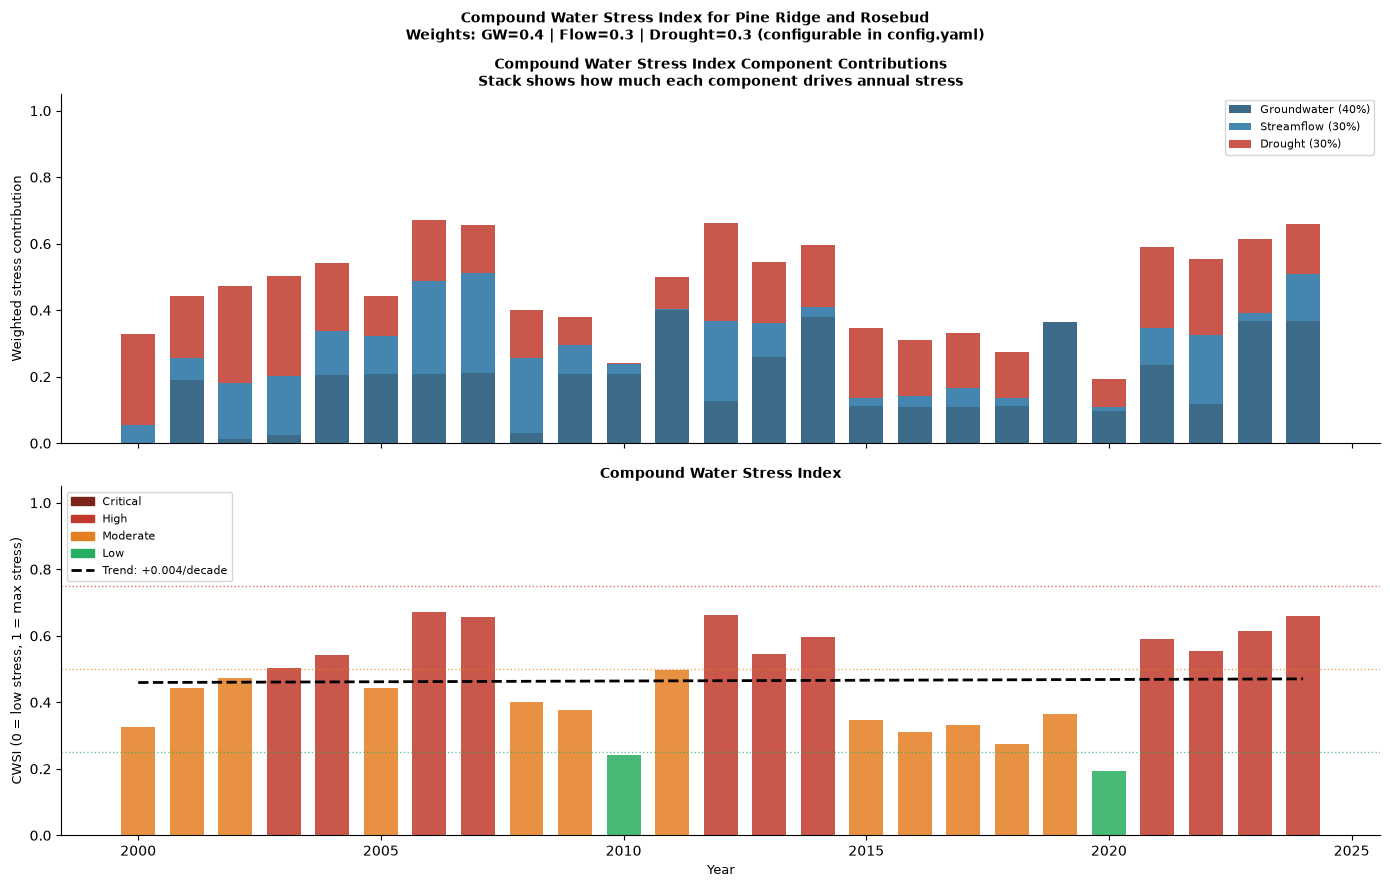


Top 5 highest-stress years:
 year  cwsi stress_class
 2006 0.673         High
 2012 0.662         High
 2024 0.659         High
 2007 0.656         High
 2023 0.613         High


In [9]:
# CWSI bar chart with component breakdown
CLASS_COLORS = {
    "Critical": "#7B241C",
    "High":     "#C0392B",
    "Moderate": "#E67E22",
    "Low":      "#27AE60",
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top: stacked component contributions
ax = axes[0]
bottom = np.zeros(len(cwsi_df))
component_colors = {
    "groundwater": "#1A5276",
    "streamflow":  "#2471A3",
    "drought":     "#C0392B",
}
component_weights = {
    "groundwater": WEIGHTS["groundwater"],
    "streamflow":  WEIGHTS["streamflow"],
    "drought":     WEIGHTS["drought"],
}

for comp, color in component_colors.items():
    if comp in normalized:
        w        = component_weights[comp]
        vals     = normalized[comp].reindex(cwsi_df["year"]).fillna(0).values * w
        ax.bar(cwsi_df["year"], vals, bottom=bottom,
               color=color, alpha=0.85, width=0.7,
               label=f"{comp.title()} ({int(w*100)}%)"),
        bottom += vals

ax.set_ylabel("Weighted stress contribution", fontsize=9)
ax.set_title(
    "Compound Water Stress Index Component Contributions\n"
    "Stack shows how much each component drives annual stress",
    fontsize=10, fontweight="bold",
)
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)
despine(ax)

# Bottom: CWSI with stress class coloring
ax = axes[1]
bar_colors = [
    CLASS_COLORS.get(str(cls), "#566573")
    for cls in cwsi_df["stress_class"]
]
ax.bar(cwsi_df["year"], cwsi_df["cwsi"], color=bar_colors, alpha=0.85, width=0.7)

for threshold, label, color in [
    (0.25, "Low/Moderate",    "#27AE60"),
    (0.50, "Moderate/High",   "#E67E22"),
    (0.75, "High/Critical",   "#C0392B"),
]:
    ax.axhline(threshold, color=color, linewidth=1, linestyle=":", alpha=0.7)

# Trend line
trend = theilsen_trend(cwsi_df["cwsi"].values, cwsi_df["year"].values.astype(float))
yrs   = cwsi_df["year"].values.astype(float)
t_line = trend["slope"] * (yrs - yrs.mean()) + cwsi_df["cwsi"].mean()
ax.plot(cwsi_df["year"], t_line, color="black", linewidth=2, linestyle="--",
        label=f"Trend: {trend['slope_per_decade']:+.3f}/decade "
              f"({'sig.' if trend['significant'] else 'not sig.'})")

ax.set_ylabel("CWSI (0 = low stress, 1 = max stress)", fontsize=9)
ax.set_xlabel("Year", fontsize=9)
ax.set_title("Compound Water Stress Index", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.legend(
    handles=[
        mpatches.Patch(color=v, label=k)
        for k, v in CLASS_COLORS.items()
    ] + [plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2,
                    label=f"Trend: {trend['slope_per_decade']:+.3f}/decade")],
    fontsize=8, loc="upper left",
)
despine(ax)

plt.suptitle(
    "Compound Water Stress Index for Pine Ridge and Rosebud\n"
    f"Weights: GW={WEIGHTS['groundwater']} | Flow={WEIGHTS['streamflow']} | "
    f"Drought={WEIGHTS['drought']} (configurable in config.yaml)",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
try:
    fig.savefig(FIGURES_DIR/"06_compound_stress_index.png",
                dpi=150, bbox_inches="tight")
except Exception:
    pass
plt.show()

print(f"\nTop 5 highest-stress years:")
print(cwsi_df.nlargest(5, "cwsi")[["year", "cwsi", "stress_class"]].to_string(index=False))

## Sensitivity Analysis: What If Weights Change?

In [7]:
# Show how the top-ranked stress years change under different weight assumptions
# This transparency is important when presenting to Tribal decision-makers

scenarios = {
    "Default (GW 40 / Flow 30 / Drought 30)": WEIGHTS,
    "Groundwater-heavy (GW 60 / Flow 20 / Drought 20)": {
        "groundwater": 0.60, "streamflow": 0.20, "drought": 0.20
    },
    "Drought-heavy (GW 20 / Flow 20 / Drought 60)": {
        "groundwater": 0.20, "streamflow": 0.20, "drought": 0.60
    },
    "Equal weights (GW 33 / Flow 33 / Drought 33)": {
        "groundwater": 0.33, "streamflow": 0.33, "drought": 0.34
    },
}

print("SENSITIVITY: Top 3 stress years under different weight scenarios")

for label, weights in scenarios.items():
    alt_cwsi = compute_compound_stress_index(
        groundwater_stress = normalized.get("groundwater"),
        streamflow_stress  = normalized.get("streamflow"),
        drought_stress     = normalized.get("drought"),
        gw_weight     = weights.get("groundwater", 0),
        flow_weight   = weights.get("streamflow", 0),
        drought_weight= weights.get("drought", 0),
    )
    if isinstance(alt_cwsi, pd.Series):
        alt_cwsi.index = years
    alt_df   = pd.Series(alt_cwsi.values, index=years).sort_values(ascending=False)
    top3     = alt_df.head(3)
    top3_str = ", ".join([f"{int(yr)} ({v:.2f})" for yr, v in top3.items()])
    print(f"\n  {label}:")
    print(f"    Top 3: {top3_str}")

print()
print("If the top-ranked years are consistent across all scenarios,")
print("the finding is robust regardless of exact weight choices.")

SENSITIVITY: Top 3 stress years under different weight scenarios

  Default (GW 40 / Flow 30 / Drought 30):
    Top 3: 2006 (0.67), 2012 (0.66), 2024 (0.66)

  Groundwater-heavy (GW 60 / Flow 20 / Drought 20):
    Top 3: 2024 (0.74), 2014 (0.71), 2023 (0.71)

  Drought-heavy (GW 20 / Flow 20 / Drought 60):
    Top 3: 2012 (0.81), 2003 (0.73), 2002 (0.70)

  Equal weights (GW 33 / Flow 33 / Drought 33):
    Top 3: 2012 (0.70), 2006 (0.69), 2007 (0.67)

If the top-ranked years are consistent across all scenarios,
the finding is robust regardless of exact weight choices.


## Exports

In [8]:
cwsi_df.to_csv(OUTPUTS_DIR/"compound_water_stress_index.csv", index=False)
print("Exported to outputs/compound_water_stress_index.csv")
print()
print("This file feeds into:")
print("  pipeline/compute_stages.py operational drought stage trigger")
print("  app/app.py dashboard CWSI panel")

Exported to outputs/compound_water_stress_index.csv

This file feeds into:
  pipeline/compute_stages.py operational drought stage trigger
  app/app.py dashboard CWSI panel


## Summary and Findings

*(Fill in after running.)*

**Highest stress years:**  
Which years rank as Critical? Are 2002 and 2012 consistently at the top?
What does the component breakdown show, was 2012 high primarily
because of drought stress, or did streamflow and groundwater also
contribute?

**Trend:**  
Is the CWSI trend increasing? A significant positive trend would mean
compound water stress is worsening over the record period, a finding
directly relevant to Tribal water planning and infrastructure investment.

**Sensitivity:**  
Are the top-ranked stress years stable across weight scenarios? If so,
the finding is robust. If not, document which component drives the
instability. This guides where to invest in better data collection.

**For decision-makers:**  
The CWSI is not a prediction, it is a historical synthesis. Present
it to Tribal water staff as: "In years when the CWSI was above 0.75,
these things tended to happen..." Let the community decide what score
should trigger what response.